In [63]:
# building a basic chatbot using langgraph(graph api)

In [64]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # it will append the messages in any variable we will define instead of replacing it. and add_messages in a reducer which means it will not replace the messages. 

In [65]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages] # add the messages in list rather than overriding or replacing it

graph_builder = StateGraph(State) 

graph_builder

In [66]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [67]:
from langchain_groq import ChatGroq

model = ChatGroq(
    model="openai/gpt-oss-120b",
)

In [68]:
# creating a node
def chatbot(state:State):
    return {"messages": [model.invoke(state["messages"])]}

# state["messages"] is the input message. and as soon as we are getting the messages we are  giving it to chatbot node and it will provide a response and will append that response it to "messages" which is defined in class above.


In [69]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot", chatbot)

## Adding Edges
graph_builder.add_edge(START, "llmchatbot") 
graph_builder.add_edge("llmchatbot", END)

# START -> llmchatbot -> END

#compile the graph to execute it.
graph = graph_builder.compile()

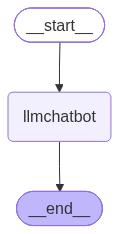

In [70]:
#visualizing the graph
from IPython.display import Image, display

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [71]:
response = graph.invoke({"messages": "Hi"})

In [72]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='f756f7c4-73c2-4a66-abf5-c8583bb02633'),
 AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond appropriately. No special instructions. Just greet back.'}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 72, 'total_tokens': 111, 'completion_time': 0.080929081, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.002867445, 'prompt_tokens_details': None, 'queue_time': 0.280837909, 'total_time': 0.083796526}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_df9620fe21', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a051a6-91de-7663-9754-8a4199d1cb70-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 39, 'total_tokens': 111, 'output_token_details': {'reasoning': 21}}

In [73]:
# This(response["messages"]) is the message variable that we had created in (messages: Annotated[list, add_messages] )
response["messages"][-1]

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond appropriately. No special instructions. Just greet back.'}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 72, 'total_tokens': 111, 'completion_time': 0.080929081, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.002867445, 'prompt_tokens_details': None, 'queue_time': 0.280837909, 'total_time': 0.083796526}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_df9620fe21', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a051a6-91de-7663-9754-8a4199d1cb70-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 39, 'total_tokens': 111, 'output_token_details': {'reasoning': 21}})

In [74]:
response["messages"][-1].content

'Hello! How can I help you today?'

In [75]:
# or we can also display the message using stream
for event in graph.stream({"messages": "Hi how are you"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="Hello! I'm doing great, thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hi how are you". We can respond politely. There\'s no policy conflict. So answer friendly.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 75, 'total_tokens': 133, 'completion_time': 0.119287374, 'completion_tokens_details': {'reasoning_tokens': 32}, 'prompt_time': 0.003309909, 'prompt_tokens_details': None, 'queue_time': 0.366086434, 'total_time': 0.122597283}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a051a6-9450-7912-b6f1-7a646f53d54b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 58, 'total_tokens': 133, 'output_token_details': {'reasoning': 32}})]}}


In [76]:
for event in graph.stream({"messages": "Hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I’m doing great, thank you. How can I help you today?


In [77]:
# creating chatbot with tool 
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results= 2)
tool.invoke("What is AI")

{'query': 'What is AI',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'What is Artificial Intelligence (AI)?',
   'url': 'https://cloud.google.com/learn/what-is-artificial-intelligence',
   'content': "Artificial intelligence (AI) is a set of technologies that empowers computers to learn, reason, and perform a variety of advanced tasks in ways that used to require human intelligence, such as understanding language, analyzing data, and even providing helpful suggestions. It’s a transformational technology that can bring meaningful and positive change to people and societies and the world. [...] Artificial intelligence techniques, though diverse, all fundamentally rely on data, algorithms, and computational power. AI systems learn and improve through exposure to vast amounts of data, identifying patterns and relationships that humans might miss. This data serves as the training material, the quality and quantity of which are crucial for the AI's per

In [78]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [79]:
tools=[tool, multiply]

In [80]:
llm_with_tool = model.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.11'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000225378B5C10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000225378B6B40>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, a

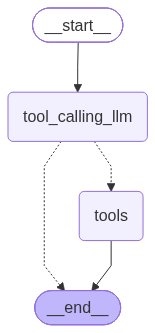

In [81]:
# Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


## Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Grpah

builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edges

builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools",END)


## compile the graph

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [82]:
response = graph.invoke({"messages":"What is recent AI news"})

In [83]:
response

{'messages': [HumanMessage(content='What is recent AI news', additional_kwargs={}, response_metadata={}, id='bd475250-0834-4209-aff1-9dbb57a5fd32'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is recent AI news". We need to provide recent AI news. Likely need to browse for up-to-date information. Use search. Let\'s search news for AI recent.', 'tool_calls': [{'id': 'fc_585f7ef3-1ba6-4047-b5a9-9cd9873b3d9e', 'function': {'arguments': '{"query":"latest AI news August 2026","search_depth":"advanced","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 347, 'total_tokens': 446, 'completion_time': 0.209260971, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.020143034, 'prompt_tokens_details': None, 'queue_time': 0.160680046, 'total_time': 0.229404005}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6de

In [84]:
response['messages'][-1].content

'{"query": "latest AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ts2.tech/en/salesforce-stock-adds-1-6-on-2-3x-volume-as-ai-rally-nears-analyst-ceiling", "title": "Salesforce Shares Lift 1.6% on 2.3x Volume as AI Surge Tests Analyst Price Targets", "content": "## Related articles: NYSE:CRM\\n\\nSalesforce Shares Jump 22.6% with AI and Data ARR Approaching $3.9 Billion \\n\\n28 August 2026\\n\\n### Salesforce Shares Jump 22.6% with AI and Data ARR Approaching $3.9 Billion\\n\\n27 August 2026\\n\\n### ServiceNow Shares Surge 9%—$11.7 Billion Gain Linked to Salesforce AI Results Shifting Software Valuations\\n\\nSalesforce Shares Surge 11% Before Market Open, AI ARR Reaches $3.9 Billion, Market Value Increases by $18.5 Billion \\n\\n27 August 2026\\n\\n### Salesforce Shares Surge 11% Before Market Open, AI ARR Reaches $3.9 Billion, Market Value Increases by $18.5 Billion\\n\\nSalesforce Gains 12.7%, Market Value Rises by $22.

In [85]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_585f7ef3-1ba6-4047-b5a9-9cd9873b3d9e)
 Call ID: fc_585f7ef3-1ba6-4047-b5a9-9cd9873b3d9e
  Args:
    query: latest AI news August 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ts2.tech/en/salesforce-stock-adds-1-6-on-2-3x-volume-as-ai-rally-nears-analyst-ceiling", "title": "Salesforce Shares Lift 1.6% on 2.3x Volume as AI Surge Tests Analyst Price Targets", "content": "## Related articles: NYSE:CRM\n\nSalesforce Shares Jump 22.6% with AI and Data ARR Approaching $3.9 Billion \n\n28 August 2026\n\n### Salesforce Shares Jump 22

In [86]:
response = graph.invoke({"messages":"What is 2 multiply by 3"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3
================================== Ai Message ==================================

2 × 3 = 6.


In [87]:
response = graph.invoke({"messages":"Give me the recent AI news and then multiply 2 by 3"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 2 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_e03402e6-2e24-4a86-a26a-c813c1bc7e2a)
 Call ID: fc_e03402e6-2e24-4a86-a26a-c813c1bc7e2a
  Args:
    query: artificial intelligence news recent week
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "artificial intelligence news recent week", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Aug 25, 2026\n\n## August 13, 2026\n\n6sense launched product updates that route revenue data directly into external artificial intelligence software. The updates 

In [88]:
# LLM gave the result of tavily search but not of the second question. 
# https://youtu.be/rV3HJ4LEZ7k?si=NKjhbyKTspj7rWmg&t=13982

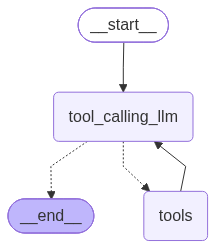

In [90]:
# using reAct agent architecture

# Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


## Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Grpah

builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edges

builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

# builder.add_edge("tools",END) instead of going to END, it will go abck to tool calling llm
builder.add_edge("tools","tool_calling_llm")


## compile the graph

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [91]:
response = graph.invoke({"messages":"Give me the recent AI news and then multiply 2 by 3"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 2 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_ab80794a-e9cc-4951-a658-f47c055af9be)
 Call ID: fc_ab80794a-e9cc-4951-a658-f47c055af9be
  Args:
    query: latest AI news September 2026
    search_depth: fast
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://artlybot.com/latest-ai-news-september-2025-2026", "title": "Parked Domain name on Hostinger DNS system", "content": "Registered at\n\nIf this is your domain, you can manage it in your Hostinger account.\n\nManage domain\n\n## Start your online journey\n\n### Build your website today\n\nLaunch your business with WordPress or Website Buil

In [92]:
# adding the memory
response = graph.invoke({"messages":"Hello my name is Ritesh"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ritesh
================================== Ai Message ==================================

Hello Ritesh! Nice to meet you. How can I assist you today?


In [93]:
response = graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don’t have any record of your name, so I’m not able to answer that. If you’d like me to refer to you by a specific name, just let me know!


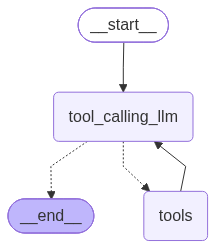

In [94]:
# It is not persisting the entire information wrt to previous conversation. so memory solve this persistence

# Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Grpah

builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edges

builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

# builder.add_edge("tools",END) instead of going to END, it will go abck to tool calling llm
builder.add_edge("tools","tool_calling_llm")


## compile the graph

graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [95]:
# if we want to use this specific memory for context of the previous interaction, so for this we need to create a thread id

config={"configurable":{"thread_id": "1"}}
response = graph.invoke({"messages": "My name is Ritesh"}, config=config)
response

{'messages': [HumanMessage(content='My name is Ritesh', additional_kwargs={}, response_metadata={}, id='fb2c3f21-1aa8-4843-9a78-f2f30b47ae09'),
  AIMessage(content='Nice to meet you, Ritesh! How can I assist you today?', additional_kwargs={'reasoning_content': 'We have a user message: "My name is Ritesh". Likely they want a response acknowledging. There\'s no question. The assistant should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 348, 'total_tokens': 406, 'completion_time': 0.120080382, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.018222249, 'prompt_tokens_details': None, 'queue_time': 0.31211796, 'total_time': 0.138302631}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c652c0ffaa', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a052ac-76a1-7e32-9103-5312471ab554-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'

In [96]:
response["messages"][-1].content

'Nice to meet you, Ritesh! How can I assist you today?'

In [98]:
response = graph.invoke({"messages": "What is my name"}, config=config)
response["messages"][-1].content

'Your name is Ritesh.'

In [99]:
# streaming in langgraph
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [109]:
def superbot(state: State):
    return {"messages": [model.invoke(state["messages"])]}

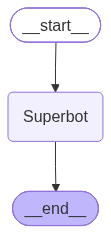

In [110]:
graph = StateGraph(State)

# node
graph.add_node("Superbot", superbot)

# edge
graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile(checkpointer=memory)

# display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [111]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket."},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket.', additional_kwargs={}, response_metadata={}, id='e677916c-8c49-4166-aafc-f3135465fbd8'),
  HumanMessage(content='Hi,My name is Krish And I like cricket.', additional_kwargs={}, response_metadata={}, id='e514735b-db20-4789-868a-300d4c970a9c'),
  HumanMessage(content='Hi,My name is Krish And I like cricket.', additional_kwargs={}, response_metadata={}, id='15bad768-f17f-4dbe-986c-14a335dde389'),
  AIMessage(content='Hey Krish! Nice to meet you. 😊\n\nCricket’s a fantastic sport—do you have a favorite team or player? Are you more into watching the matches, playing yourself, or maybe both? Let me know what you enjoy most about cricket!', additional_kwargs={'reasoning_content': 'The user repeats the same message three times. Likely they want a response acknowledging and maybe ask about cricket. Should respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 115, 'total_tokens

In [ ]:
# https://youtu.be/rV3HJ4LEZ7k?si=5PlcRo8FXWMo4rLX&t=15077

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages":"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

# we did not get the human message, which one was the last message we got that.

{'Superbot': {'messages': [AIMessage(content='Hello Krish! 👋 Nice to meet you.  \n\nCricket’s a fantastic sport—whether you’re into the fast‑paced excitement of T20, the strategic depth of Test cricket, or anything in between. Do you have a favorite team or player? Or perhaps there’s a particular match or tournament you’ve been following lately? Let me know, and we can chat all things cricket!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". Likely they want a response. Should greet, ask about cricket, maybe ask what they want. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_tokens': 82, 'total_tokens': 211, 'completion_time': 0.27030436, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.003565117, 'prompt_tokens_details': None, 'queue_time': 0.359731079, 'total_time': 0.273869477}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a78f200e', 'service_tier': 'o

In [ ]:
# changing mode = values
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages":"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

# In this AI message got also appended.

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='eda0ecae-5691-42a0-b1e4-a517fce1e0f3'), AIMessage(content='Hello Krish! 👋 Nice to meet you.  \n\nCricket’s a fantastic sport—whether you’re into the fast‑paced excitement of T20, the strategic depth of Test cricket, or anything in between. Do you have a favorite team or player? Or perhaps there’s a particular match or tournament you’ve been following lately? Let me know, and we can chat all things cricket!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". Likely they want a response. Should greet, ask about cricket, maybe ask what they want. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_tokens': 82, 'total_tokens': 211, 'completion_time': 0.27030436, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.003565117, 'prompt_tokens_details': None, 'queue_time

In [ ]:
# astream method
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":" I also like basketball"},config, version="v2"):
    print(event)

# for debugging it helps to understand all the events.

{'event': 'on_chain_start', 'data': {'input': {'messages': ' I also like basketball'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a052c2-5be8-7af1-a02e-1457fc1150e8', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content=' I also like basketball', additional_kwargs={}, response_metadata={}, id='141aad5c-3666-49a8-81f1-6e800949d19a'), AIMessage(content='That’s awesome! Basketball is such a fun sport—whether you love the fast‑break action, the strategy of the half‑court sets, or just the excitement of a buzzer‑beater.  \n\nDo you have a favorite team or player you follow? Maybe you’re into the NBA, college hoops, or even international leagues? If you’re looking for something new, I can suggest some classic games to watch, highlight reels of legendary performances, or even some drills and workouts if you play yourself. Let me know what you’re most interested in, and we can dive 